# 1 - FM Grundlagen

## Überblick: Frequenzmodulation (FM)

Unmodulierter Träger:

$$s_c(t) = U_c \cos(2\pi f_c t + \varphi_c)$$

Basisbandsignal (z. B. Cosinus):

$$u_m(t) = U_m \cos(2\pi f_m t + \varphi_m)$$

FM über die Phasenintegration:

$$s_{FM}(t) = U_c \cos\left(2\pi f_c t + 2\pi k_f \int_0^t u_m(\tau)\,d\tau + \varphi_c\right)$$

Für normiertes Basisbandsignal $\hat u_m(t)$ und Frequenzhub $\Delta f$:

$$f_i(t) = f_c + \Delta f\,\hat u_m(t)$$

Modulationsindex $\eta$:
$$\eta = \frac{\Delta f}{f_m}$$

Näherung der belegten Bandbreite (Carson):

$$B_C \approx 2(\Delta f + f_m)$$

## Globale Konfiguration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Globale Parameter
T_obs = 0.02            # Beobachtungsdauer [s]
fs = 200_000            # Abtastrate [Hz]
N_sig = int(T_obs * fs) # Anzahl Signalpunkte
N_fft = 16384           # FFT-Länge

# Optionale FFT-Fensterung gegen Leakage
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'

# Erzeugung eines Zeitvektors t für die gesamte Beobachtungsdauer T_obs mit N_sig Signalpunkten
t_plot_ms = 6.0         # konsistente Plotdauer [ms]
t = np.arange(N_sig) / fs
n_plot = min(N_sig, int(t_plot_ms * 1e-3 * fs))

## Erzeugung eines unmodulierten Trägersignals

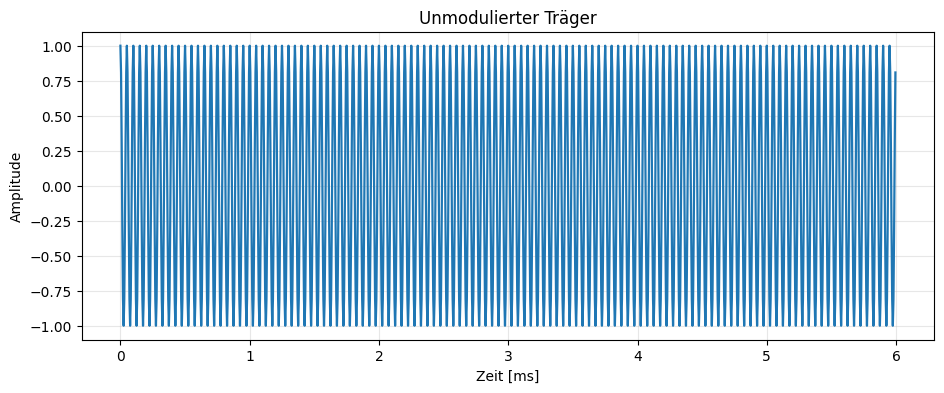

In [2]:
# 1) Unmodulierter Träger: Parameter + Signal
U_c = 1.0              # Trägeramplitude
f_c = 20_000.0         # Trägerfrequenz [Hz]
phi_c_deg = 0.0        # Trägerphase [deg]

phi_c = np.deg2rad(phi_c_deg)
s_c = U_c * np.cos(2*np.pi*f_c*t + phi_c)

plt.figure(figsize=(11, 4))
plt.plot(t[:n_plot]*1e3, s_c[:n_plot], lw=1.6)
plt.title('Unmodulierter Träger')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.show()

## Erzeugung eines Basisbandsignals

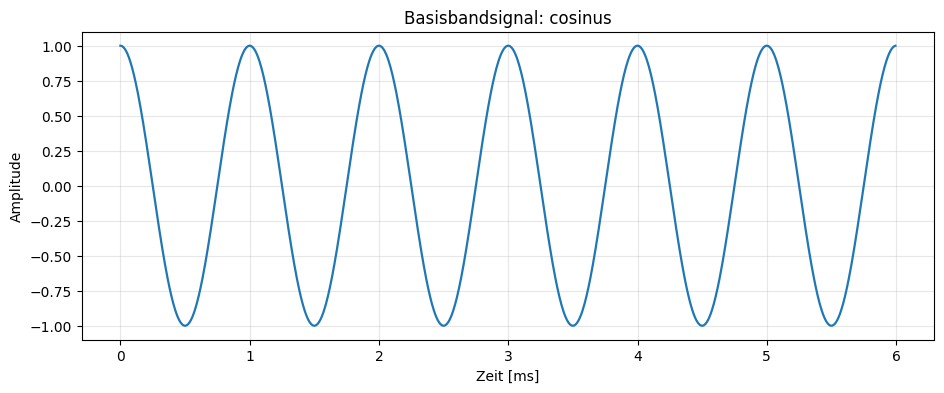

In [3]:
# 2) Basisbandsignal: Auswahl + Parameter
# wave_type in {'cosinus', 'dreieck', 'rechteck'}
wave_type = 'cosinus'

U_m = 1.0              # Basisbandamplitude
f_m = 1_000.0          # Basisbandfrequenz [Hz]
phi_m_deg = 0.0        # Basisbandphase [deg]

phi_m = np.deg2rad(phi_m_deg)
x = 2*np.pi*f_m*t + phi_m

if wave_type == 'cosinus':
    u_m = U_m * np.cos(x)
elif wave_type == 'dreieck':
    # Dreieck ohne SciPy, normiert in [-1, 1]
    tri = (2/np.pi) * np.arcsin(np.sin(x))
    u_m = U_m * tri
elif wave_type == 'rechteck':
    sq = np.sign(np.sin(x))
    sq[sq == 0] = 1.0
    u_m = U_m * sq
else:
    raise ValueError('wave_type muss cosinus, dreieck oder rechteck sein')

plt.figure(figsize=(11, 4))
plt.plot(t[:n_plot]*1e3, u_m[:n_plot], lw=1.6)
plt.title(f'Basisbandsignal: {wave_type}')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.show()

## Prinzip der FM

Didaktische Sicht:

1. Wir bilden aus dem Basisband ein normiertes Signal $\hat u_m(t)$.
2. Daraus entsteht die zeitabhängige Frequenzabweichung $\Delta f\,\hat u_m(t)$.
3. Durch Integration der Momentanfrequenz erhalten wir die FM-Phase.

Mit Frequenzhub $\Delta f$ gilt:

$$\varphi_{FM}(t) = 2\pi f_c t + 2\pi \Delta f\int_0^t \hat u_m(\tau)\,d\tau + \varphi_c$$
$$s_{FM}(t) = U_c\cos(\varphi_{FM}(t))$$

FM-Modulationsindex:

$$\eta = \frac{\Delta f}{f_m}$$

## TODO: Implementierung der Frequenz-Modulation

In [7]:
# 3) FM-Modulator (Python-Implementierung)

# Ersetze die Platzhalter durch sinnvolle Werte

delta_f = 15000 # Frequenzhub [Hz] fuer U_m = 1.0

u_m_hat = u_m / np.max(np.abs(u_m)) if np.max(np.abs(u_m)) > 0 else u_m

# Numerische Integration der normierten Nachricht
dt = 1 / fs  # fs muss im vorherigen Code definiert sein
int_u = np.cumsum(u_m_hat) * dt

phi_fm = 2 * np.pi * f_c * t + 2 * np.pi * delta_f * int_u
s_fm = np.cos(phi_fm)

eta = delta_f / f_m if f_m > 0 else 0
B_carson = 2 * (delta_f + f_m)

print(f'delta_f = {delta_f:.1f} Hz, f_m = {f_m:.1f} Hz, eta = {eta:.3f}')
print(f'Carson-Bandbreite B_C ~ {B_carson:.1f} Hz')

delta_f = 15000.0 Hz, f_m = 1000.0 Hz, eta = 15.000
Carson-Bandbreite B_C ~ 32000.0 Hz


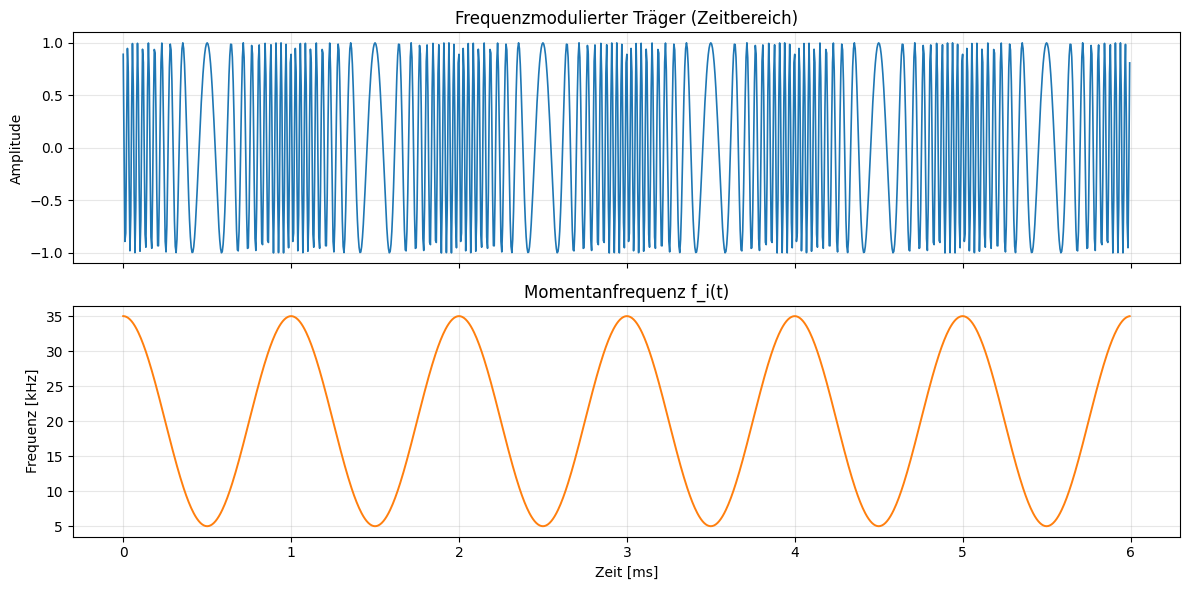

In [8]:
# Plot: FM-Signal und Momentanfrequenz
f_inst = f_c + delta_f * u_m_hat

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, s_fm[:n_plot], lw=1.2)
ax[0].set_title('Frequenzmodulierter Träger (Zeitbereich)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, f_inst[:n_plot]/1e3, color='tab:orange', lw=1.4)
ax[1].set_title('Momentanfrequenz f_i(t)')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('Frequenz [kHz]')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 4a) Peak-Suche als eigene Funktion (Sliding-Window-Maximum, ohne SciPy)
def find_peaks_sliding_window(a: np.ndarray, k: int = 21, min_height: float = 0.0, return_window_max: bool = False):
    x = np.asarray(a, dtype=float).ravel()
    n = x.size
    if n == 0:
        if return_window_max:
            return np.array([], dtype=int), np.array([], dtype=float)
        return np.array([], dtype=int)

    k = max(3, int(k))
    if k % 2 == 0:
        k += 1
    h = k // 2

    max_filt = np.empty(n, dtype=float)
    for i in range(n):
        i0 = max(0, i - h)
        i1 = min(n, i + h + 1)
        max_filt[i] = np.max(x[i0:i1])

    cand = np.isclose(x, max_filt, rtol=0.0, atol=1e-14) & (x >= float(min_height))
    idx = np.flatnonzero(cand)
    if idx.size == 0:
        if return_window_max:
            return np.array([], dtype=int), max_filt
        return np.array([], dtype=int)

    groups = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    peaks = []
    for g in groups:
        j = g[np.argmax(x[g])]
        peaks.append(int(j))

    peaks = np.array(peaks, dtype=int)
    if return_window_max:
        return peaks, max_filt
    return peaks

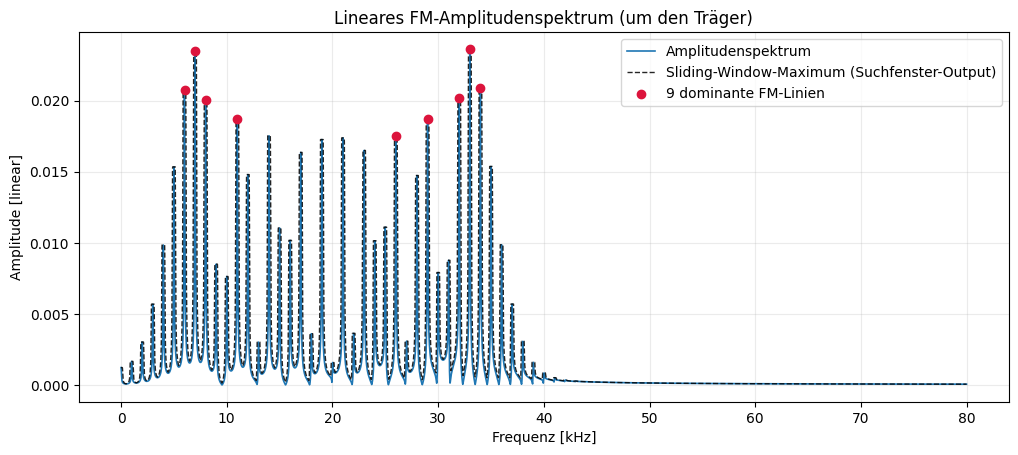

Spektrale Auflösung: df = 12.207 Hz
Peak-Suche (Sliding-Window): window = 20 Bins (~250.0 Hz), min_height >= 7.0898e-04
FM-Modulationsindex eta = 15.000
Carson-Bandbreite: B_C ~ 32000.0 Hz
Beobachtete Bandbreite aus detektierten Linien: ~ 27990.7 Hz

--- Erkannte FM-Spektrallinien (Tabelle) ---


,Ordnung n (nahe),Frequenz [Hz],Delta zu Träger [Hz],Amplitude [linear],Amplitude normiert auf Träger
0,-20,6005.859375,-19995.117187,0.020752,1.183507
1,-19,6994.628906,-19006.347656,0.023498,1.340126
2,-18,7995.605469,-18005.371094,0.020026,1.142078
3,-15,10998.535156,-15002.441406,0.018695,1.066173
4,0,26000.976562,0.000000,0.017535,1.000000
5,3,29003.906250,3002.929688,0.018722,1.067750
6,6,31994.628906,5993.652344,0.020150,1.149177
7,7,32995.605469,6994.628906,0.023633,1.347774
8,8,33996.582031,7995.605469,0.020881,1.190869


In [10]:
# 4) Spektrum berechnen und plotten (lineares Amplitudenspektrum)
x_fft = np.zeros(N_fft)
n_copy = min(N_sig, N_fft)
x_fft[:n_copy] = s_fm[:n_copy]

if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w = np.hanning(N_fft)
    elif FFT_WINDOW_KIND == 'hamming':
        w = np.hamming(N_fft)
    else:
        w = np.ones(N_fft)
else:
    w = np.ones(N_fft)

X = np.fft.fft(x_fft * w, n=N_fft)
f = np.fft.fftfreq(N_fft, d=1/fs)

cg = np.mean(w)
mask = f >= 0
f_pos = f[mask]
A_pos = (2.0 / (N_fft * max(cg, 1e-12))) * np.abs(X[mask])

# Suchbereich um den Träger
span_hz = max(4*delta_f, 6*f_m)
band = (f_pos >= max(0.0, f_c - span_hz)) & (f_pos <= (f_c + span_hz))
f_band = f_pos[band]
A_band = A_pos[band]

df = fs / N_fft
peak_window_hz = max(0.25*f_m, 8*df)
peak_window_bins = max(3, int(np.round(peak_window_hz / df)))
peak_min_height = 0.03 * np.max(A_band)

peaks, A_winmax = find_peaks_sliding_window(
    A_band, k=peak_window_bins, min_height=peak_min_height, return_window_max=True
)

if peaks.size == 0:
    raise ValueError('Keine Peaks gefunden. Bitte min_height anpassen.')

top_n = min(9, peaks.size)
sel = peaks[np.argsort(A_band[peaks])[-top_n:]]
sel = sel[np.argsort(f_band[sel])]

f_lines = f_band[sel]
A_lines = A_band[sel]

carrier_idx = np.argmin(np.abs(f_lines - f_c))
f_c_est = f_lines[carrier_idx]
A_c_est = A_lines[carrier_idx]

order = np.round((f_lines - f_c_est) / max(f_m, 1e-12)).astype(int)
B_occ = f_lines.max() - f_lines.min() if f_lines.size > 1 else 0.0

plt.figure(figsize=(12, 4.8))
plt.plot(f_band/1e3, A_band, lw=1.2, label='Amplitudenspektrum')
plt.plot(f_band/1e3, A_winmax, 'k--', lw=1.0, alpha=0.85, label='Sliding-Window-Maximum (Suchfenster-Output)')
plt.scatter(f_lines/1e3, A_lines, color='crimson', zorder=4, label=f'{top_n} dominante FM-Linien')
plt.title('Lineares FM-Amplitudenspektrum (um den Träger)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [linear]')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f'Spektrale Auflösung: df = {df:.3f} Hz')
print(f'Peak-Suche (Sliding-Window): window = {peak_window_bins} Bins (~{peak_window_hz:.1f} Hz), min_height >= {peak_min_height:.4e}')
print(f'FM-Modulationsindex eta = {eta:.3f}')
print(f'Carson-Bandbreite: B_C ~ {B_carson:.1f} Hz')
print(f'Beobachtete Bandbreite aus detektierten Linien: ~ {B_occ:.1f} Hz')

df_lines = pd.DataFrame({
    'Ordnung n (nahe)': order,
    'Frequenz [Hz]': f_lines,
    'Delta zu Träger [Hz]': f_lines - f_c_est,
    'Amplitude [linear]': A_lines,
    'Amplitude normiert auf Träger': A_lines / max(A_c_est, 1e-12),
}).sort_values('Frequenz [Hz]').reset_index(drop=True)

print('\n--- Erkannte FM-Spektrallinien (Tabelle) ---')
display(df_lines)

## Zusatz: Besselfunktionen und FM-Spektrum

Für ein sinusförmiges FM-Basisbandsignal lassen sich die Spektrallinien mit Besselfunktionen **erster Art** beschreiben:

$$s_{FM}(t) = U_c \sum_{n=-\infty}^{\infty} I_n(\eta)\cos\big(2\pi(f_c+n f_m)t + \varphi_n\big)$$

- Die Linien bei $f_c \pm n f_m$ werden durch $I_n(\eta)$ gewichtet.
- Der Modulationsindex $\eta$ steuert damit direkt die Verteilung der Spektralleistung auf Träger und Seitenlinien.


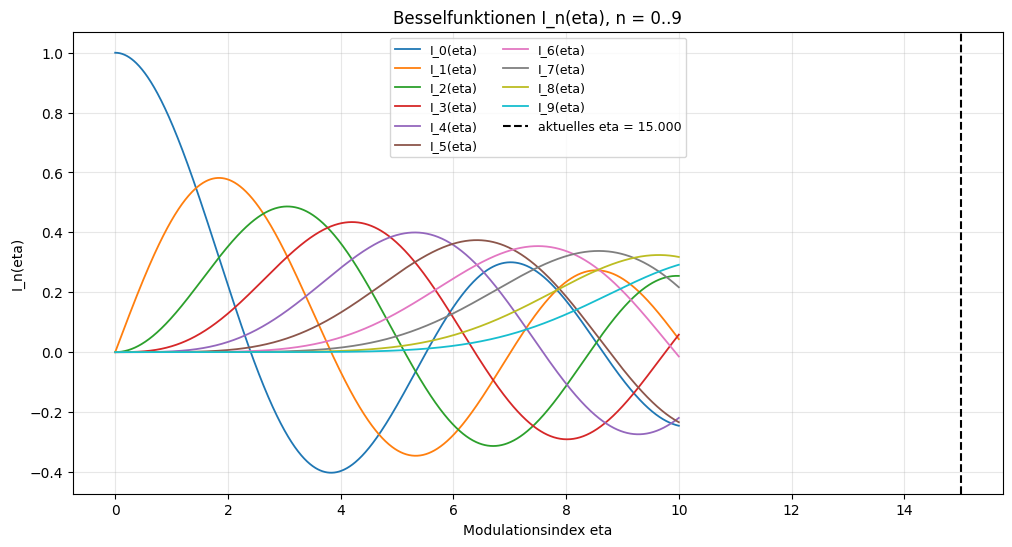

Aktueller Modulationsindex eta = 15.000000
Hinweis: Für ein sinusförmiges FM-Signal sind die Linienamplituden bei f_c ± n f_m proportional zu I_n(eta).


,Ordnung n,I_n(eta),|I_n(eta)|,relative Leistung ~ I_n(eta)^2
0,0,-0.014224,0.014224,0.000202
1,1,0.205104,0.205104,0.042068
2,2,0.041572,0.041572,0.001728
3,3,-0.194018,0.194018,0.037643
4,4,-0.119179,0.119179,0.014204
5,5,0.130456,0.130456,0.017019
6,6,0.206150,0.206150,0.042498
7,7,0.034464,0.034464,0.001188
8,8,-0.173984,0.173984,0.030270
9,9,-0.220046,0.220046,0.048420


In [11]:

# 5) Besselfunktionen I_n(eta): Plot der ersten 10 Ordnungen + Tabelle bei aktuellem eta
from math import factorial


def bessel_i_series(n: int, x: np.ndarray, terms: int = 60) -> np.ndarray:
    """Besselfunktion I_n(x) via Reihenentwicklung (ohne SciPy)."""
    x = np.asarray(x, dtype=float)
    s = np.zeros_like(x)
    for k in range(terms):
        num = (-1.0) ** k * (x / 2.0) ** (2 * k + n)
        den = factorial(k) * factorial(k + n)
        s += num / den
    return s


eta_axis = np.linspace(0.0, 10.0, 1200)
orders = list(range(10))  # n = 0..9

plt.figure(figsize=(12, 6))
for n in orders:
    In = bessel_i_series(n, eta_axis)
    plt.plot(eta_axis, In, lw=1.3, label=f'I_{n}(eta)')

plt.axvline(float(eta), color='k', linestyle='--', lw=1.5, label=f'aktuelles eta = {eta:.3f}')
plt.title('Besselfunktionen I_n(eta), n = 0..9')
plt.xlabel('Modulationsindex eta')
plt.ylabel('I_n(eta)')
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.show()

# Tabelle der Werte I_n(eta) am im Beispiel verwendeten Modulationsindex
I_eta = np.array([bessel_i_series(n, np.array([eta]))[0] for n in orders], dtype=float)

df_bessel = pd.DataFrame({
    'Ordnung n': orders,
    'I_n(eta)': I_eta,
    '|I_n(eta)|': np.abs(I_eta),
    'relative Leistung ~ I_n(eta)^2': I_eta**2,
})

print(f'Aktueller Modulationsindex eta = {eta:.6f}')
print('Hinweis: Für ein sinusförmiges FM-Signal sind die Linienamplituden bei f_c ± n f_m proportional zu I_n(eta).')
display(df_bessel)